# Configuración básica (no tocar)

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from abstractions.base import Function
from abstractions.functions import Variable, sin, cos, exp, ln

In [21]:
x = Variable()

# Implementación de métodos

In [22]:
# Implementar para hallar raíces de las derivadas, no de f

def biseccion(f: Function, a: float, b: float, tol: float = 1e-6, max_iter: int = 1000):
    df = f.derivative()
    step = 0
    dfa = df.eval(a)

    while step < max_iter and (b - a) >= tol:
        m = (a + b) / 2
        dfm = df.eval(m)
        step += 1
        if abs(dfm) < tol:
            return m, step
        if dfa * dfm < 0:
            b = m
        else:
            a = m
            dfa = dfm

    return (a + b) / 2, step

def newton(f: Function, x0: float, tol: float = 1e-6, max_iter: int = 1000):
    df  = f.derivative()
    d2f = df.derivative()
    xn  = x0
    step = 0

    while step < max_iter:
        d2f_val = d2f.eval(xn)
        if abs(d2f_val) < 1e-12:
            break
        x_new = xn - df.eval(xn) / d2f_val
        step += 1
        if abs(x_new - xn) < tol:
            return x_new, step
        xn = x_new

    return xn, step

def descenso_gradiente(f: Function, x0: float, lr: float, tol: float = 1e-6, max_iter: int = 1000):
    df = f.derivative()
    xn = x0
    step = 0

    while step < max_iter:
        x_new = xn - lr * df.eval(xn)
        step += 1
        if abs(x_new - xn) < tol:
            return x_new, step
        xn = x_new

    return xn, step

### Prueba de métodos

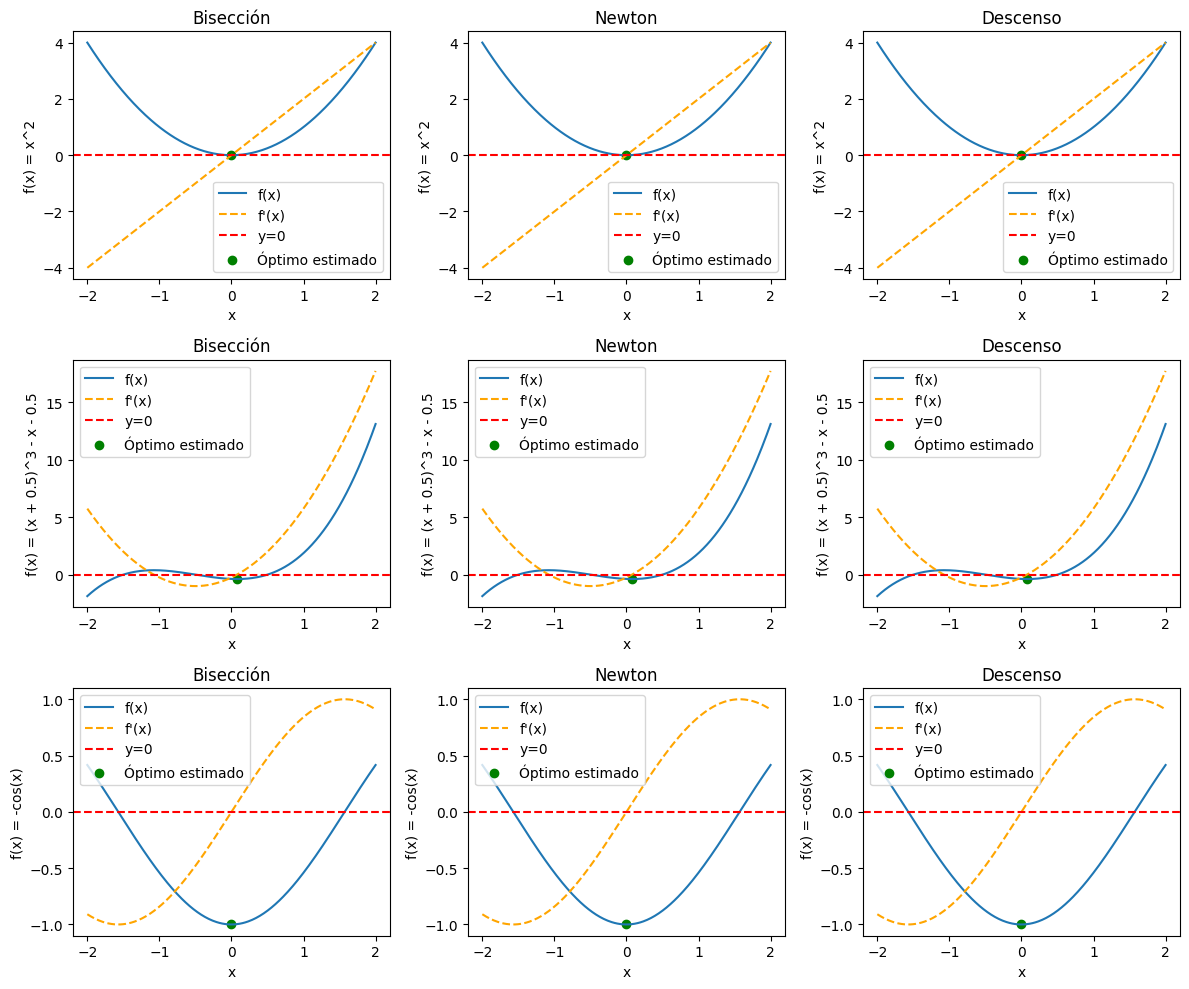

In [23]:
f1 = x**2
f2 = (x + 0.5)**3 - x - 0.5
f3 = -cos(x)

functions = [f1, f2, f3]

methods = [biseccion, newton, descenso_gradiente]
# Recomendación: exploren parámetros en esta etapa para ver distintos comportamientos.
parameters = [{"a":-1, "b":1}, {"x0": 1}, {"x0": 1, "lr": 1e-2}]

y_labels = ["f(x) = x^2", "f(x) = (x + 0.5)^3 - x - 0.5", "f(x) = -cos(x)"]
titles = ["Bisección", "Newton", "Descenso"]

lp = np.linspace(-2, 2, 300)

fig, axes = plt.subplots(3, 3, figsize=(12, 10))

for i, f in enumerate(functions):
    for j, m in enumerate(methods):
        ax = axes[i, j]
        # labels ejes
        ax.set_xlabel("x")
        ax.set_ylabel(y_labels[i])

        # métodos
        method = methods[j]
        params = parameters[j] 
        res, step = method(f, **params)

        # graficas
        ax.plot(lp, np.array(list(map(lambda v: f.eval(v), lp))))
        ax.plot(lp, np.array(list(map(lambda v: f.derivative().eval(v), lp))), linestyle="--", color="orange")
        ax.axhline(0, linestyle="--", color="red")
        ax.scatter(res, f.eval(res), color="green")

        ax.plot()
        ax.legend([f"f(x)", "f'(x)", "y=0", "Óptimo estimado"])
        ax.set_title(titles[j])

plt.tight_layout()
plt.show()

## Preguntas 2.3

### 1. ¿Pueden los métodos diferenciar un máximo de un mínimo?

No directamente. Los tres métodos buscan puntos donde **f'(x) = 0**, sin distinguir por sí solos si ese punto es un máximo, un mínimo o un punto de inflexión.

Esto se puede observar en `f2 = (x + 0.5)³ − (x + 0.5)`, cuya derivada `f2'(x) = 3(x + 0.5)² − 1` tiene dos raíces:

- `x ≈ 0.077` → **mínimo local** (f2'' > 0)
- `x ≈ −1.077` → **máximo local** (f2'' < 0)

Con el intervalo `[−1, 1]` y punto inicial `x0 = 1`, los tres métodos convergen al mínimo en `x ≈ 0.077`. Pero ninguno de ellos *"sabe"* que es un mínimo: simplemente llegan a una raíz de f'. Si se eligiera un intervalo o punto inicial distinto (por ejemplo, `x0 = −2` en Newton), podría encontrarse el máximo en `x ≈ −1.077` y el algoritmo lo devolvería de igual manera.

---

### 2. Ventajas y desventajas de cada método

| | **Bisección** | **Newton** | **Descenso por gradiente** |
|---|---|---|---|
| **Información requerida** | f' solamente | f' y f'' | f' solamente |
| **Condición inicial** | Intervalo [a, b] con f'(a)·f'(b) < 0 | Punto x₀ | Punto x₀ y learning rate lr |
| **Velocidad de convergencia** | Lineal (lenta: ~21 iters para 1e-6) | Cuadrática (muy rápida: 2–6 iters) | Lineal y dependiente de lr (hasta 927 iters) |
| **Garantía de convergencia** | Sí, si la condición de signos se cumple | No garantizada | No garantizada |
| **Robustez ante no convexidad** | Solo encuentra el extremo en el intervalo dado | Puede divergir o saltar a otro extremo | Puede quedar atrapado en extremos locales |
| **Fallo característico** | Requiere conocer un intervalo con signos opuestos en f', lo que implica conocimiento previo de la función | Se indefine si f''(xn) ≈ 0 (punto de inflexión) | lr muy grande → diverge; lr muy pequeño → convergencia lentísima |

**Conclusión:** 

Newton es el más eficiente cuando f'' existe y no se anula cerca de la solución. 

Bisección es el más robusto si se dispone de un buen intervalo inicial.

Descenso por gradiente es el más flexible (no requiere f'' ni intervalo), pero es el más lento y el más sensible a la elección de lr.

# Aplicación a función no trivial

In [24]:
f = x**2 + 2*sin(3*x)

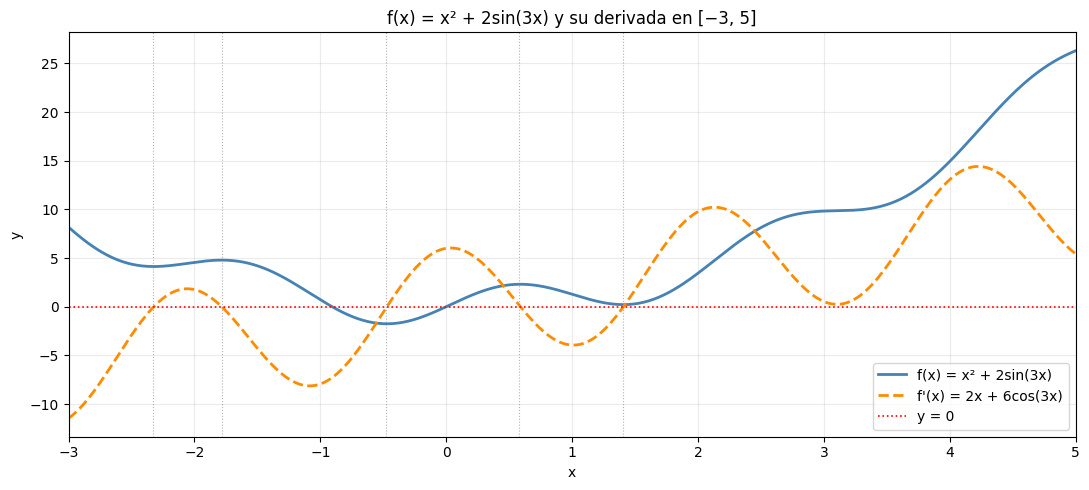

Extremos locales detectados: 5
  x ≈ -2.332  →  mínimo local  (f(x) ≈ 4.1303)
  x ≈ -1.785  →  máximo local  (f(x) ≈ 4.7873)
  x ≈ -0.476  →  mínimo local  (f(x) ≈ -1.7531)
  x ≈ 0.579  →  máximo local  (f(x) ≈ 2.3077)
  x ≈ 1.407  →  mínimo local  (f(x) ≈ 0.2163)


In [25]:
# Grafica de la función
df = f.derivative()

lp = np.linspace(-3, 5, 600)
f_vals  = np.array([f.eval(v)  for v in lp])
df_vals = np.array([df.eval(v) for v in lp])

fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(lp, f_vals,  label="f(x) = x² + 2sin(3x)",  color="steelblue",  linewidth=2)
ax.plot(lp, df_vals, label="f'(x) = 2x + 6cos(3x)", color="darkorange", linewidth=2, linestyle="--")
ax.axhline(0, color="red", linestyle=":", linewidth=1.2, label="y = 0")

# líneas verticales en cada cruce de f' con y=0 (extremos aproximados de f)
cruces = np.where(np.diff(np.sign(df_vals)) != 0)[0]
for idx in cruces:
    ax.axvline(lp[idx], color="gray", linestyle=":", linewidth=0.8, alpha=0.6)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("f(x) = x² + 2sin(3x) y su derivada en [−3, 5]")
ax.legend()
ax.grid(True, alpha=0.25)
ax.set_xlim(-3, 5)

plt.tight_layout()
plt.show()

print(f"Extremos locales detectados: {len(cruces)}")
for idx in cruces:
    xc = lp[idx]
    tipo = "mínimo" if df_vals[idx] < 0 else "máximo"
    print(f"  x ≈ {xc:.3f}  →  {tipo} local  (f(x) ≈ {f.eval(xc):.4f})")

In [36]:
predicciones = {
    ("Bisección",  "[-2, 1]"):         "máximo x≈-1.783",
    ("Bisección",  "[-1, 0]"):         "mínimo x≈-0.476",
    ("Bisección",  "[1, 2]"):          "mínimo x≈1.408",
    ("Newton",     "x0=-2"):           "máximo x≈-1.783",
    ("Newton",     "x0=-1"):           "máximo x≈0.589",
    ("Newton",     "x0=4"):            "diverge",
    ("Descenso",   "x0=-3, lr=1e-2"):  "mínimo x≈-2.332",
    ("Descenso",   "x0=0.585, lr=1e-2"): "mínimo x≈-0.476",
    ("Descenso",   "x0=4, lr=1e-2"):   "mínimo x≈1.408",
    ("Descenso",   "x0=-3, lr=1e-3"):  "mínimo x≈-2.332",
    ("Descenso",   "x0=0.585, lr=1e-3"): "mínimo x≈-0.476",
    ("Descenso",   "x0=4, lr=1e-3"):   "mínimo x≈1.408",
    ("Descenso",   "x0=-3, lr=5e-2"):  "mínimo x≈-2.332",
    ("Descenso",   "x0=0.585, lr=5e-2"): "mínimo x≈-0.476",
    ("Descenso",   "x0=4, lr=5e-2"):   "mínimo x≈1.408",
}

filas = []

# Bisección
for a, b in [(-2, 1), (-1, 0), (1, 2)]:
    cond = f"[{a}, {b}]"
    xn, iters = biseccion(f, a, b)
    filas.append({"Método": "Bisección", "Condición inicial": cond,
                  "Predicción": predicciones[("Bisección", cond)],
                  "xn": round(xn, 4), "f(xn)": round(f.eval(xn), 4), "Iters": iters})

# Newton
for x0 in [-2, -1, 4]:
    cond = f"x0={x0}"
    xn, iters = newton(f, x0)
    filas.append({"Método": "Newton", "Condición inicial": cond,
                  "Predicción": predicciones[("Newton", cond)],
                  "xn": round(xn, 4), "f(xn)": round(f.eval(xn), 4), "Iters": iters})

# Descenso por gradiente (3 learning rates)
for lr in [1e-3, 1e-2, 5e-2]:
    for x0 in [-3, 0.585, 4]:
        lr_str = f"{lr:.0e}".replace("e-0", "e-") 
        cond = f"x0={x0}, lr={lr_str}"
        xn, iters = descenso_gradiente(f, x0, lr)
        filas.append({"Método": f"Descenso lr={lr_str}", "Condición inicial": f"x0={x0}",
                      "Predicción": predicciones[("Descenso", f"x0={x0}, lr={lr_str}")],
                      "xn": round(xn, 4), "f(xn)": round(f.eval(xn), 4), "Iters": iters})

tabla = pd.DataFrame(filas)
pd.set_option("display.max_colwidth", 25)
#display(tabla.to_string(index=False))  -- Comente porque no se ve como tabla MK
display(tabla)

,Método,Condición inicial,Predicción,xn,f(xn),Iters
0,Bisección,"[-2, 1]",máximo x≈-1.783,-1.7829,4.7873,22
1,Bisección,"[-1, 0]",mínimo x≈-0.476,-0.4710,-1.7533,20
2,Bisección,"[1, 2]",mínimo x≈1.408,1.4080,0.2163,20
3,Newton,x0=-2,máximo x≈-1.783,-1.7829,4.7873,5
4,Newton,x0=-1,máximo x≈0.589,0.5895,2.3086,5
5,Newton,x0=4,diverge,7.8209,59.1762,1000
6,Descenso lr=1e-3,x0=-3,mínimo x≈-2.332,-2.3229,4.1297,636
7,Descenso lr=1e-3,x0=0.585,mínimo x≈-0.476,-0.4710,-1.7533,795
8,Descenso lr=1e-3,x0=4,mínimo x≈1.408,2.9308,9.7717,1000
9,Descenso lr=1e-2,x0=-3,mínimo x≈-2.332,-2.3228,4.1297,77


### Predicciones previas a la ejecución

Extremos de referencia detectados en la gráfica anterior:

| x ≈ | Tipo | f(x) ≈ |
|-----|------|--------|
| −2.332 | mínimo | 4.130 |
| −1.783 | máximo | 4.787 |
| −0.476 | mínimo | −1.753 |
|  0.589 | máximo | 2.309 |
|  1.408 | mínimo |  0.216 |

---

**Bisección**

- `[−2, 1]`: f'(−2) ≈ +1.76 y f'(1) ≈ −3.94 → signos opuestos. La primera bisección da m=−0.5, donde f'(−0.5)<0, por lo que el intervalo se reduce a [−2, −0.5]. El único cambio de signo en ese tramo es el **máximo en x≈−1.783**. → **máximo x≈−1.783**

- `[−1, 0]`: f'(−1) ≈ −7.94 y f'(0) = +6 → hay un mínimo en el intervalo. El único extremo en [−1, 0] es el **mínimo en x≈−0.476**. → **mínimo x≈−0.476**

- `[1, 2]`: f'(1) ≈ −3.94 y f'(2) ≈ +9.76 → el único extremo en [1, 2] es el **mínimo en x≈1.408**. → **mínimo x≈1.408**

---

**Newton**

- `x0 = −2`: f'(−2)≈+1.76 y **f''(−2)≈−3.03 < 0** → el paso es x_new = −2 − (+1.76)/(−3.03) ≈ −1.42, empujando hacia la derecha. La curvatura negativa señala que estamos en la parte descendente de f', convergiendo al **máximo en x≈−1.783**.

- `x0 = −1`: f'(−1)≈−7.94 y f''(−1)≈+4.54 → paso grande hacia la derecha: x_new≈0.75. Desde allí, las iteraciones convergen al **máximo en x≈0.589** (el cambio de signo más cercano a ese salto).

- `x0 = 4`: f'(4)≈+13 y f''(4)≈+11.65 → primer paso a x≈2.88. Desde ahí, f'' cambia de signo frecuentemente y Newton oscila sin converger. **Se predice divergencia o convergencia lenta a un punto lejano.**

---

**Descenso por gradiente**

- `x0 = −3`: f'(−3)≈−11.47 < 0 → el gradiente es negativo, se mueve a la derecha hacia el primer mínimo que encuentre, el **mínimo en x≈−2.332**.

- `x0 = 0.585`: f'(0.585)≈+0.07 > 0 (pequeño) → se mueve ligeramente a la izquierda. Entre x=−0.476 y x=0.589, f' es positiva a lo largo de todo el tramo (f es creciente), así que el descenso avanza hacia la izquierda hasta el **mínimo en x≈−0.476**. Convergencia lenta por gradiente pequeño.

- `x0 = 4`: f'(4)≈+13 > 0 → se mueve a la izquierda. No hay más extremos entre 1.408 y 5, así que converge directamente al **mínimo en x≈1.408**.

In [38]:
# Análisis de learning rates — descenso_gradiente con x0=0.585
lrs_analisis = [1e-4, 1e-3, 1e-2, 5e-2, 1e-1, 3e-1]
x0_analisis  = 0.585

filas_lr = []
for lr in lrs_analisis:
    xn, iters = descenso_gradiente(f, x0_analisis, lr)
    convergio = iters < 1000
    filas_lr.append({
        "lr": lr,
        "xn": round(xn, 4),
        "f(xn)": round(f.eval(xn), 4),
        "Iters": iters,
        "¿Convergió?": "✓" if convergio else "✗",
    })

tabla_lr = pd.DataFrame(filas_lr)
#display(tabla_lr.to_string(index=False)) -- Comente porque no se ve como tabla MK
display(tabla_lr)

,lr,xn,f(xn),Iters,¿Convergió?
0,0.0001,0.5678,2.3048,1000,✗
1,0.0010,-0.4710,-1.7533,795,✓
2,0.0100,-0.4710,-1.7533,89,✓
3,0.0500,-0.4710,-1.7533,14,✓
4,0.1000,-0.4710,-1.7533,511,✓
5,0.3000,-1.3366,3.3131,1000,✗


## Análisis de learning rates

### Resultados con `x0 = 0.585`

| lr | xn | f(xn) | Iters | ¿Convergió? |
|----|-----|-------|-------|-------------|
| `1e-4` | 0.5678 | 2.3048 | 1000 | ✗ |
| `1e-3` | −0.4710 | −1.7533 | 795 | ✓ |
| `1e-2` | −0.4710 | −1.7533 | 89 | ✓ |
| `5e-2` | −0.4710 | −1.7533 | 14 | ✓ |
| `1e-1` | −0.4710 | −1.7533 | 511 | ✓ |
| `3e-1` | 0.8932 | 1.6892 | 1000 | ✗ |

---

### ¿Qué pasa con un lr muy pequeño? (`lr = 1e-4`)

El gradiente en `x0 = 0.585` es casi nulo: `f'(0.585) ≈ 0.07`. Con `lr = 1e-4`, cada paso vale apenas `1e-4 × 0.07 ≈ 7×10⁻⁶`. El método avanza tan lento que en 1000 iteraciones solo recorre `≈0.017` unidades, quedando detenido en `x ≈ 0.568`, lejos del mínimo en `−0.476`. **El lr es tan pequeño que el criterio de parada por tolerancia (`|Δx| < 1e-6`) tampoco se activa**, porque los pasos son todos del orden de `7×10⁻⁶`, justo por encima de la tolerancia.

---

### ¿Qué pasa con un lr muy grande? (`lr = 3e-1`)

Con `lr = 3e-1`, el primer paso es:
```
x₁ = 0.585 − 0.3 × 0.07 ≈ 0.564
```
El paso inicial es pequeño (por el gradiente casi nulo), pero al acercarse a la zona de máximo en `x ≈ 0.589`, el gradiente cambia de signo y el método rebota hacia la derecha. La región entre `x ≈ 0.589` (máximo) y el siguiente mínimo involucra gradientes de magnitud mayor, y con `lr = 3e-1` los pasos son suficientemente grandes para saltar ese mínimo y quedar atrapado oscilando en otra región. Tras 1000 iteraciones el método termina en `x ≈ 0.893`, un punto sin extremo relevante.

---

### ¿Existe un rango "seguro"?

Para este problema y este punto inicial, el rango `lr ∈ [1e-3, 1e-1]` converge al mínimo correcto en `x ≈ −0.476`. Sin embargo, el comportamiento varía mucho dentro de ese rango:

- **`lr = 1e-3`**: 795 iteraciones. Converge pero muy lento.
- **`lr = 1e-2`**: 89 iteraciones. Buen balance velocidad/estabilidad.
- **`lr = 5e-2`**: 14 iteraciones. El más eficiente.
- **`lr = 1e-1`**: 511 iteraciones. Converge, pero oscila alrededor del mínimo antes de estabilizarse (más iteraciones que con `lr = 5e-2`).

El rango "seguro" no es universal: depende de la función, del punto inicial y de la escala del gradiente en esa región. Para `f = x² + 2sin(3x)` cerca de `x = 0.585`, el gradiente es pequeño, lo que permite `lr` más grandes de lo habitual. Sin embargo, si el mismo `lr = 1e-1` se aplica desde `x0 = 4` (donde `f'(4) ≈ 13`), el paso sería `0.1 × 13 = 1.3`, potencialmente saltando por encima del mínimo.

**Conclusión:** No existe un lr universalmente seguro. La elección óptima requiere conocer la magnitud del gradiente en la región de interés o aplicar estrategias adaptativas como *line search* o *learning rate decay*.

## BONUS 3.2

In [39]:
# Copias de métodos anterioresque devuelven la sucesión de aproximaciones

def biseccion_hist(f: Function, a: float, b: float, tol: float = 1e-6, max_iter: int = 1000):
    df = f.derivative()
    step = 0
    dfa = df.eval(a)
    history = []
    while step < max_iter and (b - a) >= tol:
        m = (a + b) / 2
        dfm = df.eval(m)
        step += 1
        history.append(m)
        if abs(dfm) < tol:
            return m, step, history
        if dfa * dfm < 0:
            b = m
        else:
            a = m
            dfa = dfm
    return (a + b) / 2, step, history

def newton_hist(f: Function, x0: float, tol: float = 1e-6, max_iter: int = 1000):
    df  = f.derivative()
    d2f = df.derivative()
    xn  = x0
    step = 0
    history = [x0]
    while step < max_iter:
        d2f_val = d2f.eval(xn)
        if abs(d2f_val) < 1e-12:
            break
        x_new = xn - df.eval(xn) / d2f_val
        step += 1
        history.append(x_new)
        if abs(x_new - xn) < tol:
            return x_new, step, history
        xn = x_new
    return xn, step, history

def descenso_hist(f: Function, x0: float, lr: float, tol: float = 1e-6, max_iter: int = 1000):
    df = f.derivative()
    xn = x0
    step = 0
    history = [x0]
    while step < max_iter:
        x_new = xn - lr * df.eval(xn)
        step += 1
        history.append(x_new)
        if abs(x_new - xn) < tol:
            return x_new, step, history
        xn = x_new
    return xn, step, history

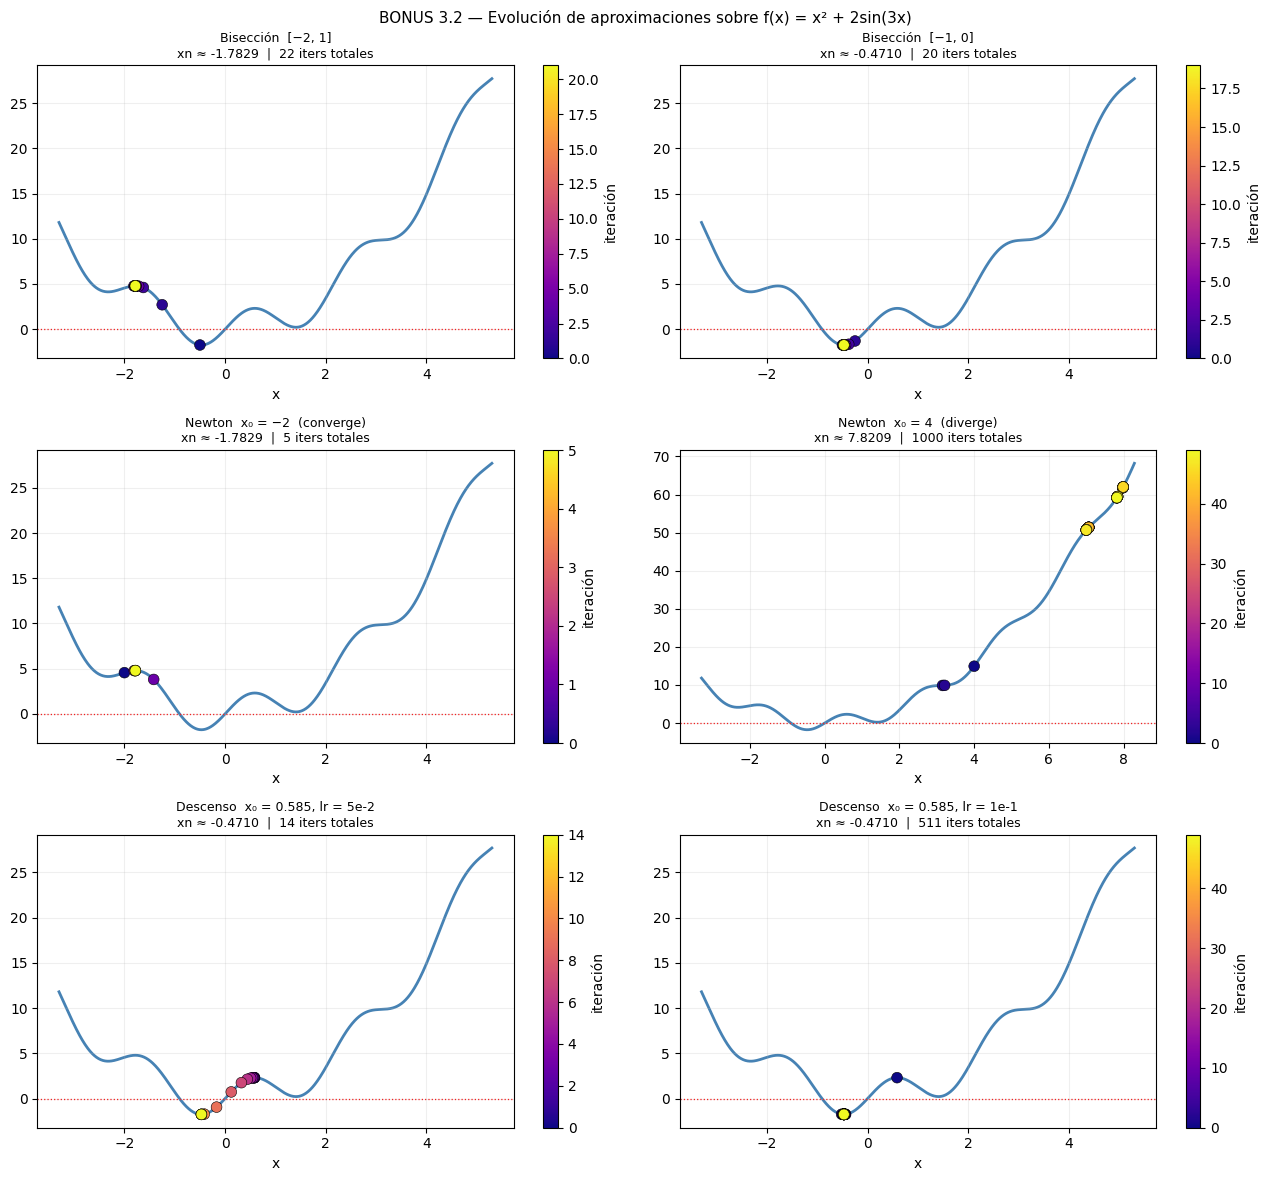

In [40]:
def _muestrear(hist, n_max=50):
    """Si el historial tiene más de n_max puntos, se muestrean uniformemente para no saturar la gráfica."""
    n = len(hist)
    if n <= n_max:
        return list(hist)
    idx = np.round(np.linspace(0, n - 1, n_max)).astype(int)
    return [hist[i] for i in idx]

casos = [
    ("Bisección  [−2, 1]",               biseccion_hist, dict(a=-2, b=1)),
    ("Bisección  [−1, 0]",               biseccion_hist, dict(a=-1, b=0)),
    ("Newton  x₀ = −2  (converge)",      newton_hist,    dict(x0=-2)),
    ("Newton  x₀ = 4  (diverge)",        newton_hist,    dict(x0=4)),
    ("Descenso  x₀ = 0.585, lr = 5e-2", descenso_hist,  dict(x0=0.585, lr=5e-2)),
    ("Descenso  x₀ = 0.585, lr = 1e-1", descenso_hist,  dict(x0=0.585, lr=1e-1)),
]

fig, axes = plt.subplots(3, 2, figsize=(13, 12))

for ax, (titulo, func, params) in zip(axes.flat, casos):
    xn_final, iters, hist = func(f, **params)
    disp = _muestrear(hist)

    xs = np.array(disp, dtype=float)
    ys = np.array([f.eval(float(v)) for v in xs])

    # el fondo de la curva cubre siempre [-3, 5]; si hay puntos fuera, se extiende
    x_lo = min(-3.0, float(xs.min())) - 0.3
    x_hi = max(5.0,  float(xs.max())) + 0.3
    lp_b = np.linspace(x_lo, x_hi, 800)
    fv_b = np.array([f.eval(v) for v in lp_b])

    ax.plot(lp_b, fv_b, color="steelblue", lw=2, zorder=1)
    ax.axhline(0, color="red", ls=":", lw=0.9, zorder=1)

    n = len(disp)
    sc = ax.scatter(xs, ys, c=np.arange(n), cmap="plasma",
                    s=60, zorder=3, edgecolors="k", linewidths=0.4)
    plt.colorbar(sc, ax=ax, label="iteración")

    ax.set_title(f"{titulo}\nxn ≈ {xn_final:.4f}  |  {iters} iters totales", fontsize=9)
    ax.set_xlabel("x")
    ax.grid(True, alpha=0.2)

plt.suptitle("BONUS 3.2 — Evolución de aproximaciones sobre f(x) = x² + 2sin(3x)", fontsize=11)
plt.tight_layout()
plt.show()

## Preguntas 3.3

### 1. ¿Los métodos funcionaron como se esperaba para las condiciones iniciales?

**Bisección: los tres casos coincidieron con la predicción.**

- `[−2, 1]` → máximo x≈−1.783 ✓. El intervalo contenía exactamente un cambio de signo de f' y la bisección lo localizó sin ambigüedad.
- `[−1, 0]` → mínimo x≈−0.476 ✓. Mismo razonamiento.
- `[1, 2]` → mínimo x≈1.408 ✓. Idéntico.

**Newton: dos correctos, uno divergió como se predijo.**

- `x0 = −2` → **máximo** x≈−1.783 ✓. Se predijo correctamente: f''(−2)≈−3.03 < 0 hace que el primer paso vaya a la derecha, hacia el máximo, no hacia el mínimo geográficamente más cercano en x≈−2.332. Newton no garantiza converger al extremo más próximo; converge al que resulta de la dinámica f'/f''.
- `x0 = −1` → **máximo** x≈0.589 ✓. f''(−1)>0 pero el paso inicial es tan grande que salta la región y cae en la cuenca del máximo en 0.589.
- `x0 = 4` → **diverge** ✓. En esa región f'' cambia de signo repetidamente; Newton oscila sin encontrar dirección estable y termina en x≈7.82 tras 1000 iteraciones.

**Descenso por gradiente: dos no convergieron.**

- `x0 = −3`, todos los lr → mínimo x≈−2.332 ✓.
- `x0 = 0.585`, `lr ∈ {1e-3, 1e-2, 5e-2, 1e-1}` → mínimo x≈−0.476 ✓.
- `x0 = 0.585`, `lr = 1e-4` → **no convergió** en 1000 iteraciones ✗. No se predijo explícitamente. El gradiente inicial es casi nulo (f'(0.585)≈0.07), y con un lr tan pequeño el paso es de orden 7×10⁻⁶, apenas por encima de la tolerancia. El método nunca activa el criterio de parada y agota las iteraciones sin alejarse significativamente del punto inicial.
- `x0 = 4`, `lr ∈ {1e-2, 5e-2}` → mínimo x≈1.408 ✓.
- `x0 = 4`, `lr = 1e-3` → **no convergió** ✗. La distancia hasta el mínimo es ≈2.6 unidades y con pasos de ≈0.013 las 1000 iteraciones son insuficientes.

---

### 2. ¿Cómo obtener máximos con descenso por gradiente sin modificar el algoritmo?

Maximizar f(x) es equivalente a minimizar −f(x), ya que:

```
argmax f(x) = argmin −f(x)
```

Como `(−f)'(x) = −f'(x)`, el descenso sobre −f actualiza en la dirección opuesta al gradiente de f, es decir, asciende por f. En el caso de este proyecto, basta pasar la función negada:

```python
descenso_gradiente(-f, x0, lr)
```

El algoritmo no cambia en absoluto, solo cambia el objeto que recibe como argumento.

---

### 3. ¿Hay riesgo de no convergencia al buscar máximos desde x0 ∈ {−3, 0.585, 4}?

Aplicando descenso sobre `−f`, el método sigue la dirección de `−(−f)'(x) = +f'(x)`, es decir, **sube por f**:

- **x0 = −3**: f'(−3)≈−11.47 → descenso sobre −f da x₁ = −3 + lr·11.47, moviéndose a la derecha. El primer máximo en esa dirección es x≈−1.783. **Converge.**

- **x0 = 0.585**: f'(0.585)≈+0.07 → se mueve ligeramente a la derecha hacia el máximo en x≈0.589. **Converge**, aunque lento por el gradiente casi nulo (misma situación que con un lr pequeño en el experimento anterior).

- **x0 = 4**: f'(4)≈+13 → el método se mueve a la derecha. Para x > 1.5 no existen más máximos locales: f'(x) > 0 para x grande (la componente 2x domina), lo que implica que (−f)'(x) = −f'(x) < 0 indefinidamente. El método **diverge hacia +∞**. **Hay riesgo real de no convergencia.**

# Ajuste de datos

In [41]:
df_linear = pd.read_csv("datasets/linear_model.csv")
df_exp = pd.read_csv("datasets/exp_model.csv")
df_sin = pd.read_csv("datasets/sin_model.csv")

w = Variable()

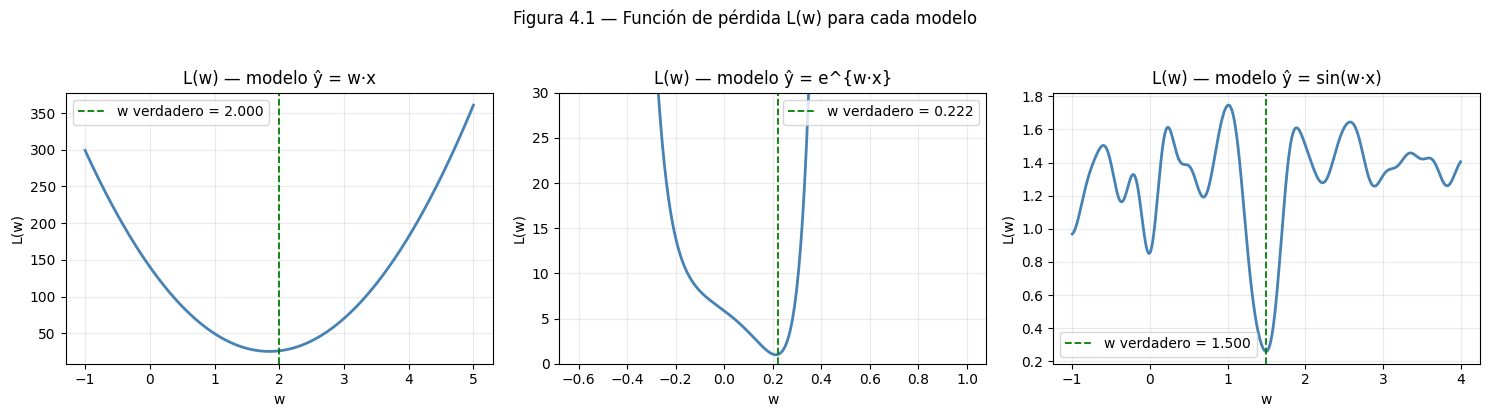

In [42]:
# 4.1 Función de pérdida: L(w) = (1/N) Σ (ŷ(xi;w) − yi)² ---
# Se construye SIMBÓLICAMENTE sobre las abstracciones: w es la Variable y cada
# (xi, yi) entra como Const. Así derivative() nos da L'(w) automáticamente.

def construir_perdida(data, modelo):
    N = len(data)
    L = None
    for xi, yi in zip(data["x"].values, data["y"].values):
        term = (modelo(xi) - (yi)) ** 2      # (ŷ(xi;w) − yi)²
        L = term if L is None else L + term
    return L * (1.0 / N)

# Modelo, dataset, etiqueta y w "verdadero" usado al generar los datos
modelos = {
    "lineal": (df_linear, lambda xi: xi * w,        "ŷ = w·x",      2.0),
    "exp":    (df_exp,    lambda xi: exp(xi * w),   "ŷ = e^{w·x}",  1/4.5),
    "sin":    (df_sin,    lambda xi: sin(xi * w),   "ŷ = sin(w·x)", 1.5),
}
perdidas = {k: construir_perdida(d, m) for k, (d, m, _, _) in modelos.items()}

# Gráfica de L(w) para cada modelo
grids = {"lineal": np.linspace(-1, 5, 400),
         "exp":    np.linspace(-0.6, 1.0, 400),
         "sin":    np.linspace(-1, 4, 800)}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (k, (d, m, lab, wt)) in zip(axes, modelos.items()):
    g = grids[k]
    vals = np.array([perdidas[k].eval(wv) for wv in g])
    ax.plot(g, vals, color="steelblue", lw=2)
    ax.axvline(wt, color="green", ls="--", lw=1.3, label=f"w verdadero = {wt:.3f}")
    ax.set_title(f"L(w) — modelo {lab}")
    ax.set_xlabel("w"); ax.set_ylabel("L(w)")
    ax.grid(alpha=0.25); ax.legend()
axes[1].set_ylim(0, 30)   # el exp explota: recortamos para ver el mínimo
plt.suptitle("Figura 4.1 — Función de pérdida L(w) para cada modelo", y=1.03)
plt.tight_layout(); plt.show()

In [45]:
# --- 4.2 Optimización de L(w) con descenso por gradiente ---
config = {  # (w0, lr) elegidos según la forma de cada L(w)
    "lineal": (0.0, 1e-2),
    "exp":    (0.0, 1e-3),   # lr chico: el gradiente exponencial es enorme
    "sin":    (1.3, 1e-2),   # arranque cerca del mínimo global (no-convexa)
}

filas = []
for k, (d, m, lab, wt) in modelos.items():
    w0, lr = config[k]
    wopt, iters = descenso_gradiente(perdidas[k], w0, lr)
    filas.append({"Modelo": lab, "w0": w0, "lr": lr,
                  "w*": round(wopt, 4), "w verdadero": round(wt, 4),
                  "L(w*)": round(perdidas[k].eval(wopt), 4), "Iters": iters})

tabla_ajuste = pd.DataFrame(filas)
print("Tabla 4.1 — Resultado del descenso por gradiente para cada modelo")
display(tabla_ajuste)

# El modelo sin es no-convexo: el resultado depende del punto inicial.
print("\nTabla 4.2 — Modelo sin(w·x): sensibilidad al punto inicial (lr = 1e-2)")
filas_sin = []
for w0 in [0.0, 0.7, 1.3, 2.2, 3.0]:
    wopt, iters = descenso_gradiente(perdidas["sin"], w0, 1e-2)
    es_global = abs(wopt - 1.5) < 0.1
    filas_sin.append({"w0": w0, "w*": round(wopt, 4),
                      "L(w*)": round(perdidas["sin"].eval(wopt), 4),
                      "Iters": iters, "¿Mínimo global?": "✓" if es_global else "✗ (local)"})
display(pd.DataFrame(filas_sin))

Tabla 4.1 — Resultado del descenso por gradiente para cada modelo


,Modelo,w0,lr,w*,w verdadero,L(w*),Iters
0,ŷ = w·x,0.0,0.010,1.8480,2.0000,25.2420,14
1,ŷ = e^{w·x},0.0,0.001,0.2126,0.2222,0.9944,14
2,ŷ = sin(w·x),1.3,0.010,1.4950,1.5000,0.2599,36



Tabla 4.2 — Modelo sin(w·x): sensibilidad al punto inicial (lr = 1e-2)


,w0,w*,L(w*),Iters,¿Mínimo global?
0,0.0,-0.0107,0.8512,10,✗ (local)
1,0.7,0.6898,1.1913,26,✗ (local)
2,1.3,1.4950,0.2599,36,✓
3,2.2,2.2229,1.2776,48,✗ (local)
4,3.0,2.8917,1.2569,57,✗ (local)


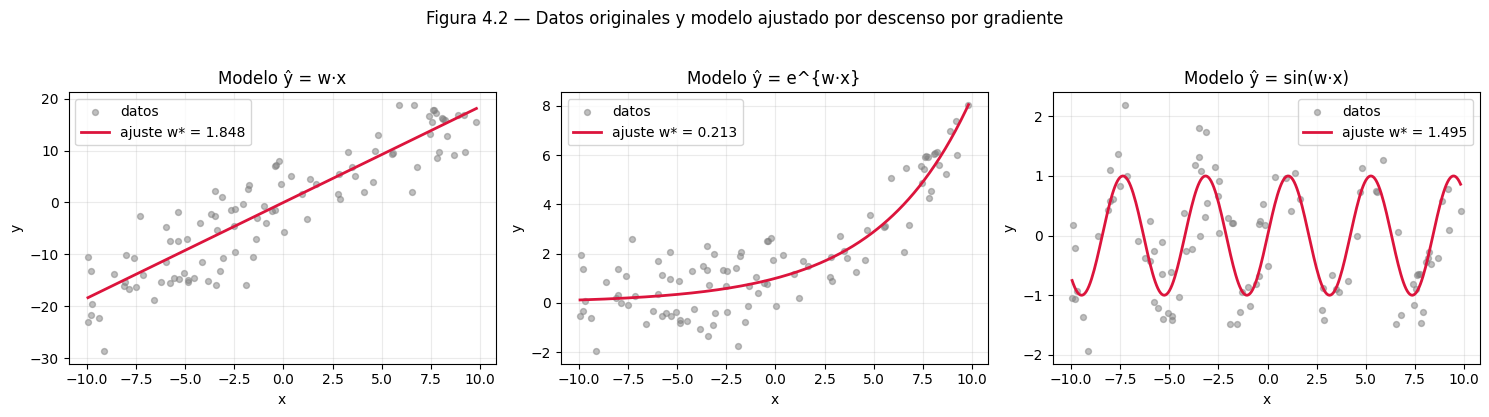

In [44]:
# --- 4.3 Datos originales vs. modelo ajustado ---
def predecir(k, wopt, xs):
    if k == "lineal": return wopt * xs
    if k == "exp":    return np.exp(wopt * xs)
    return np.sin(wopt * xs)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (k, (d, m, lab, wt)) in zip(axes, modelos.items()):
    w0, lr = config[k]
    wopt, _ = descenso_gradiente(perdidas[k], w0, lr)
    xs, ys = d["x"].values, d["y"].values
    xg = np.linspace(xs.min(), xs.max(), 300)
    ax.scatter(xs, ys, s=18, alpha=0.5, color="gray", label="datos")
    ax.plot(xg, predecir(k, wopt, xg), color="crimson", lw=2, label=f"ajuste w* = {wopt:.3f}")
    ax.set_title(f"Modelo {lab}")
    ax.set_xlabel("x"); ax.set_ylabel("y")
    ax.grid(alpha=0.25); ax.legend()
plt.suptitle("Figura 4.2 — Datos originales y modelo ajustado por descenso por gradiente", y=1.03)
plt.tight_layout(); plt.show()

# BONUS: